# 6. A complete storm-impact setup

**What this shows:** a realistic XBeach model of a swell event on a beach south of
Perth, built from real forcing data and ready to run.

**Prerequisites:** tutorials [1](01_first_model.ipynb) to
[5](05_model_settings.ipynb).

**You will learn:**

- how to combine the grid, bathymetry, forcing and components into one model
- how to check the generated workspace: `params.txt`, boundary files and forcing

**Data used:** `bathy.tif`, `ww3-spectra-20230101-short.nc` (wave spectra),
`smc-params-20230101.nc` (winds at wave model sites) and `swaus_tide_cons/` (tidal
constituents).

## Setup

In [1]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy.model import ModelRun

logging_config.update(level="WARNING")  # rompy logs every step, show warnings only

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "06_complete_setup"
shutil.rmtree(OUT_DIR, ignore_errors=True)

## 1. Period and grid

The model covers 12 hours of a SW swell event on 1 January 2023, on a 10 m x 15 m
grid.

In [2]:
from rompy_xbeach.grid import RegularGrid

period = TimeRange(start="2023-01-01T00", end="2023-01-01T12", interval="1h")

grid = RegularGrid(
    ori={"x": 115.594239, "y": -32.641104, "crs": 4326},
    alfa=347.0,
    dx=10.0,
    dy=15.0,
    nx=230,
    ny=220,
    crs=28350,
)

## 2. Bathymetry

The survey is extended to 25 m depth offshore and by 5 cells on each side.

In [3]:
from rompy_xbeach.data.bathy import SeawardExtensionLinear, XBeachBathy
from rompy_xbeach.interpolate import RegularGridInterpolator
from rompy_xbeach.source import SourceGeotiff

bathy = XBeachBathy(
    source=SourceGeotiff(filename=DATA_DIR / "bathy.tif"),
    posdwn=False,
    interpolator=RegularGridInterpolator(
        kwargs={"method": "linear", "fill_value": None}
    ),
    extension=SeawardExtensionLinear(depth=25.0, slope=0.05),
    left=5,
    right=5,
)

## 3. Forcing

**Waves:** spectra at the nearest wave model site, one SWAN file per model output
time (`filelist=True`), so the boundary follows the evolving swell. Surfbeat on a 2D
grid uses XBeach's single-direction mode by default. It propagates wave groups along
the mean direction and solves refraction on a finer directional grid set by
`dtheta_s`, so `dtheta` is not needed.

In [4]:
from rompy_xbeach.data.boundary import BoundaryStationSpectraSwan
from rompy_xbeach.source import SourceCRSWavespectra

wave = BoundaryStationSpectraSwan(
    source=SourceCRSWavespectra(
        uri=DATA_DIR / "ww3-spectra-20230101-short.nc", reader="read_ww3"
    ),
    location="offshore",
    sel_method="nearest",
    filelist=True,
    thetamin=-90.0,
    thetamax=90.0,
    dtheta_s=10.0,
)

**Wind:** interpolated from the surrounding wave model sites to the grid centre.

In [5]:
from rompy_xbeach.data.wind import WindStation, WindVector
from rompy_xbeach.source import SourceCRSFile

wind = WindStation(
    source=SourceCRSFile(uri=DATA_DIR / "smc-params-20230101.nc", crs=4326),
    coords={"s": "seapoint"},
    wind_vars=WindVector(u="uwnd", v="vwnd"),
)

**Tide:** predicted hourly from the tidal constituents at the grid centre.

In [6]:
from rompy_xbeach.data.waterlevel import TideConsGrid
from rompy_xbeach.source import SourceCRSOceantide

cons_dir = DATA_DIR / "swaus_tide_cons"
tide = TideConsGrid(
    source=SourceCRSOceantide(
        reader="read_otis_binary",
        kwargs={
            "gfile": cons_dir / "grid_m2s2n2k2k1o1p1q1mmmf",
            "hfile": cons_dir / "h_m2s2n2k2k1o1p1q1mmmf",
            "ufile": cons_dir / "u_m2s2n2k2k1o1p1q1mmmf",
        },
        crs=4326,
    ),
    coords={"x": "lon", "y": "lat"},
)

## 4. Model settings

- **Physics:** surfbeat with Manning friction. `wind=True` is needed for XBeach to use
  the wind forcing, since wind is off by default.
- **Boundaries:** absorbing-generating at the sea and back boundaries.
- **Sediment:** transport and morphology, with a morphological factor of 5.
- **Output:** hourly mean maps, bed-level snapshots, and point timeseries along a
  cross-shore transect in the middle of the grid.

The tide input sets the tide boundary itself, so `tide_boundary` is left unset.

In [7]:
from rompy_xbeach.components.boundary.parameters import FlowBoundaryConditions
from rompy_xbeach.components.output import Output
from rompy_xbeach.components.physics import Physics
from rompy_xbeach.components.physics.friction import Manning
from rompy_xbeach.components.physics.wavemodel import Surfbeat
from rompy_xbeach.components.sediment import Sediment
from rompy_xbeach.components.sediment.morphology import Morphology

transect = [(float(grid.x[110, i]), float(grid.y[110, i])) for i in (50, 150, 200)]

physics = Physics(
    wavemodel=Surfbeat(), bedfriction=Manning(bedfriccoef=0.02), wind=True
)
flow_boundary = FlowBoundaryConditions(
    front="abs_2d", back="abs_2d", left="neumann", right="neumann"
)
sediment = Sediment(sedtrans=True, morphology=Morphology(morfac=5.0, morstart=3600.0))
output = Output(
    ncfilename="xboutput.nc",
    meanvars=["H", "zs", "u", "v"],
    tintm=3600.0,
    globalvars=["zb"],
    tintg=3600.0,
    points=transect,
    pointvars=["H", "zs"],
    tintp=10.0,
)

## 5. Assemble and generate

The `Config` collects everything, and `ModelRun` writes the workspace.

In [8]:
from rompy_xbeach.config import Config, DataInterface

config = Config(
    grid=grid,
    bathy=bathy,
    input=DataInterface(wave=wave, wind=wind, tide=tide),
    physics=physics,
    flow_boundary=flow_boundary,
    sediment=sediment,
    output=output,
)

modelrun = ModelRun(
    run_id="storm_impact",
    period=period,
    output_dir=OUT_DIR,
    config=config,
)
workspace = Path(modelrun())
sorted(p.name for p in workspace.iterdir())

['bathy.txt',
 'params.txt',
 'swan-20230101T000000.txt',
 'swan-20230101T030000.txt',
 'swan-20230101T060000.txt',
 'swan-20230101T090000.txt',
 'swan-filelist.txt',
 'tide-20230101T000000-20230101T120000.txt',
 'wind-20230101T000000-20230101T120000.txt',
 'xdata.txt',
 'ydata.txt']

## 6. Check the workspace

`params.txt` combines the parameters from every object in the config. The lines
starting with `%` are a header with generation details, skipped here.

In [9]:
params_txt = (workspace / "params.txt").read_text()
print("\n".join(line for line in params_txt.splitlines() if not line.startswith("%")))


tstop = 43200.0
tunits = seconds since 2023-01-01 00:00:00
wbctype = swan
bcfile = swan-filelist.txt
thetamin = -90.0
thetamax = 90.0
dtheta_s = 10.0
dtbc = 1.0
windfile = wind-20230101T000000-20230101T120000.txt
zs0file = tide-20230101T000000-20230101T120000.txt
tideloc = 1
tidelen = 13
front = abs_2d
back = abs_2d
left = neumann
right = neumann
posdwn = -1
vardx = 0
nx = 253
ny = 229
dx = 10.0
dy = 15.0
xori = 367894.2822054199
yori = 6387607.499765068
alfa = 347.0
projection = +proj=utm +zone=50 +south +ellps=GRS80 +units=m +no_defs +type=crs
depfile = bathy.txt
wavemodel = surfbeat
bedfriction = manning
bedfriccoef = 0.02
wind = 1
sedtrans = 1
morphology = 1
morfac = 5.0
morstart = 3600.0
outputformat = netcdf
ncfilename = xboutput.nc
tintg = 3600.0
tintm = 3600.0
tintp = 10.0
npoints = 3
369003.35662210465 6389121.824346607
369977.7266868899 6388896.873292263
370464.9117192825 6388784.397765091
nmeanvar = 4
H
zs
u
v
nglobalvar = 1
zb
npointvar = 2
H
zs


The wave `bcfile` is a filelist: each line gives the duration, time step and SWAN file
used for one period of the boundary.

In [10]:
print((workspace / "swan-filelist.txt").read_text())

FILELIST
10800 1 swan-20230101T000000.txt
10800 1 swan-20230101T030000.txt
10800 1 swan-20230101T060000.txt
10800 1 swan-20230101T090000.txt



Plotting the forcing timeseries is a quick check that the right data were selected
for the right period.

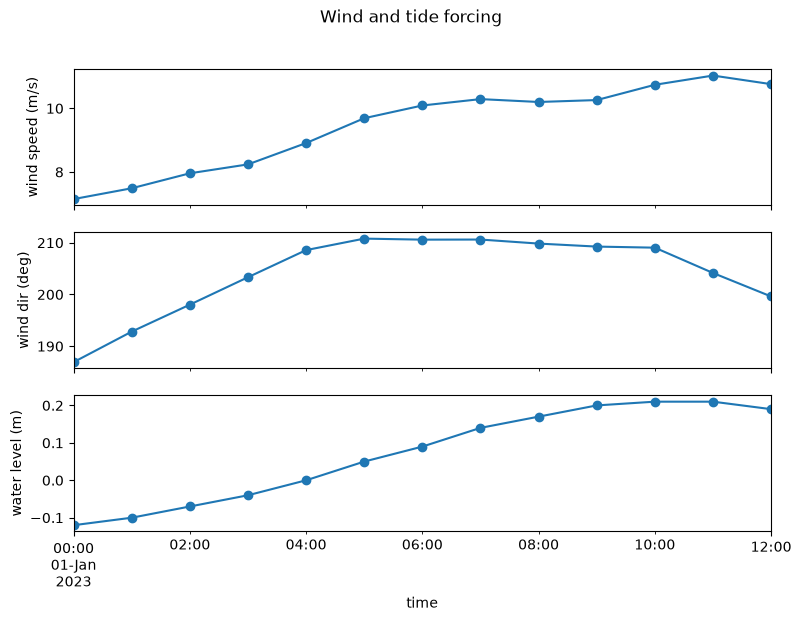

In [11]:
def read_timeseries(filename, columns):
    """Read an XBeach forcing timeseries into a dataframe indexed by time."""
    df = pd.read_csv(filename, sep=r"\s+", header=None, names=["tsec", *columns])
    df.index = period.start + pd.to_timedelta(df.pop("tsec"), unit="s")
    df.index.name = "time"
    return df


params = config.params
winds = read_timeseries(
    workspace / params["windfile"], ["wind speed (m/s)", "wind dir (deg)"]
)
tides = read_timeseries(workspace / params["zs0file"], ["water level (m)"])

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for ax, series in zip(axes, [winds.iloc[:, 0], winds.iloc[:, 1], tides.iloc[:, 0]]):
    series.plot(ax=ax, marker="o")
    ax.set_ylabel(series.name)
fig.suptitle("Wind and tide forcing")
plt.show()

## Next steps

- Run this workspace with XBeach, as in [Tutorial 1](01_first_model.ipynb#8.-Run-XBeach)
  or with the options in [Running XBeach](../examples/running_xbeach.ipynb).
  A 12-hour surfbeat run on this grid takes a while on one core, so MPI helps.
- Store the same model as a YAML file:
  [7. Configuration as YAML and the rompy CLI](07_yaml_and_cli.ipynb).